## Visualizzare i dati con Matplotlib e Seaborn


### 1. Preparazione

Importiamo tre librerie:

- `numpy` per numeri e array;
- `pandas` per dati in forma di tabella;
- `matplotlib.pyplot` per costruire e modificare grafici;
- `seaborn` per grafici statistici comodi e leggibili.



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
np.random.seed(42)


Se un'importazione produce `ModuleNotFoundError`, installa i pacchetti in una nuova cella con:

```python
%pip install matplotlib seaborn pandas numpy
```

Poi riavvia il kernel ed esegui di nuovo le celle dall'inizio.


### 2. Il primo grafico a linee

Un grafico a linee è adatto quando l'ordine dei punti ha significato, per esempio nel tempo.

Qui `x` contiene gli anni e `y` contiene le vendite. `plt.plot(x, y)` associa ogni anno alla vendita nella stessa posizione.


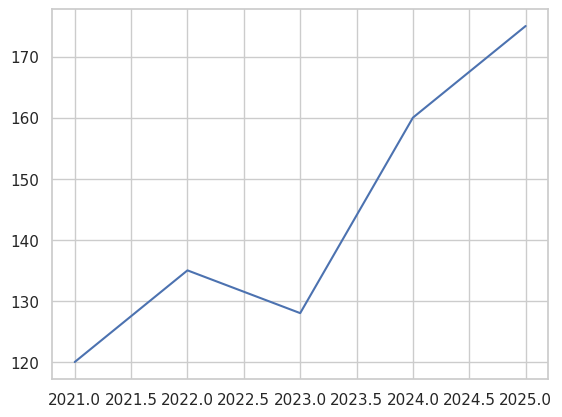

In [2]:
anni = [2021, 2022, 2023, 2024, 2025]
vendite = [120, 135, 128, 160, 175]

plt.plot(anni, vendite)
plt.show()


`plt.show()` conclude il grafico e lo visualizza. Ora aggiungiamo gli elementi necessari per farlo capire a chi non conosce i dati:

- un titolo preciso;
- i nomi e le unità degli assi;
- marcatori per vedere le osservazioni reali;
- una griglia leggera.


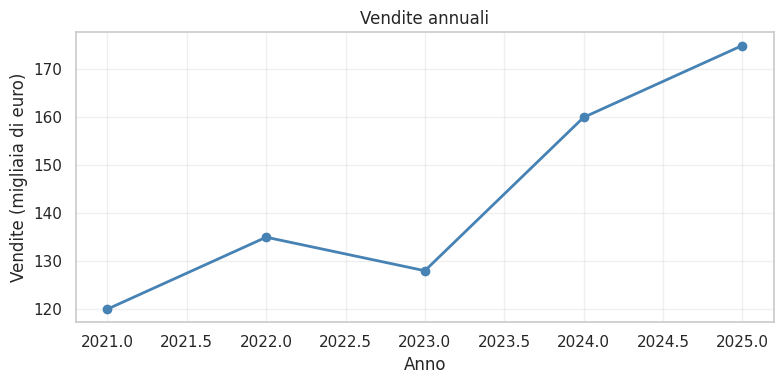

In [3]:
plt.figure(figsize=(8, 4))
plt.plot(anni, vendite, marker="o", color="steelblue", linewidth=2)
plt.title("Vendite annuali")
plt.xlabel("Anno")
plt.ylabel("Vendite (migliaia di euro)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


Come leggere il grafico: individua prima gli assi e le unità, poi cerca andamento, massimo, minimo e cambiamenti insoliti. In questo esempio le vendite calano leggermente nel 2023 e raggiungono il massimo nel 2025.


### Esercizio 1 — linea

Crea una lista `temperature = [8, 10, 14, 18, 23, 27]` e una lista con i mesi da gennaio a giugno.

1. Disegna la temperatura nel tempo.
2. Aggiungi marcatori, titolo ed etichette con unità in °C.
3. Usa un colore diverso.

Scrivi la soluzione nella cella vuota seguente.


In [ ]:
# Scrivi qui la tua soluzione


### Soluzione guidata 1

Confronta solo dopo aver provato. Le stringhe dei mesi diventano automaticamente etichette dell'asse x.


In [ ]:
mesi = ["Gen", "Feb", "Mar", "Apr", "Mag", "Giu"]
temperature = [8, 10, 14, 18, 23, 27]

plt.figure(figsize=(8, 4))
plt.plot(mesi, temperature, marker="o", color="tomato")
plt.title("Temperatura media mensile")
plt.xlabel("Mese")
plt.ylabel("Temperatura (°C)")
plt.tight_layout()
plt.show()


### 3. Più serie e legenda

Possiamo chiamare `plot` più volte sugli stessi assi. L'argomento `label` assegna un nome a ogni linea; `plt.legend()` mostra quei nomi.


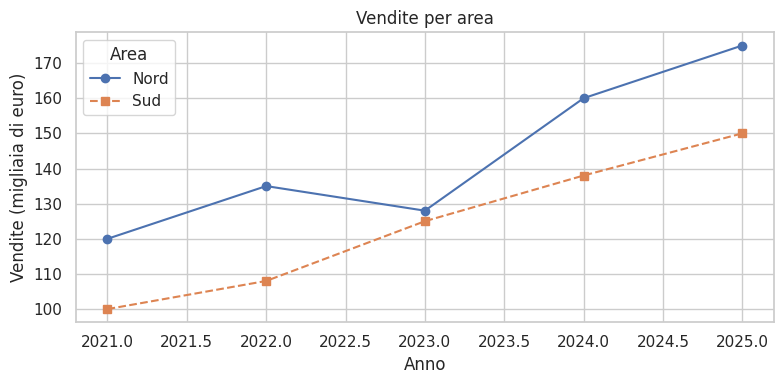

In [3]:
vendite_nord = [120, 135, 128, 160, 175]
vendite_sud = [100, 108, 125, 138, 150]

plt.figure(figsize=(8, 4))
plt.plot(anni, vendite_nord, marker="o", label="Nord")
plt.plot(anni, vendite_sud, marker="s", linestyle="--", label="Sud")
plt.title("Vendite per area")
plt.xlabel("Anno")
plt.ylabel("Vendite (migliaia di euro)")
plt.legend(title="Area")
plt.tight_layout()
plt.show()


Attenzione: troppe linee e troppi colori rendono il grafico difficile da leggere. Se le categorie sono molte, valuta piccoli grafici separati.


### 4. Figura e assi: il metodo consigliato

Matplotlib distingue:

- `fig`, l'intera figura;
- `ax`, l'area con coordinate, titolo e dati.

La forma `fig, ax = plt.subplots()` è utile perché rende esplicito su quale asse stiamo lavorando. È particolarmente comoda con più grafici.


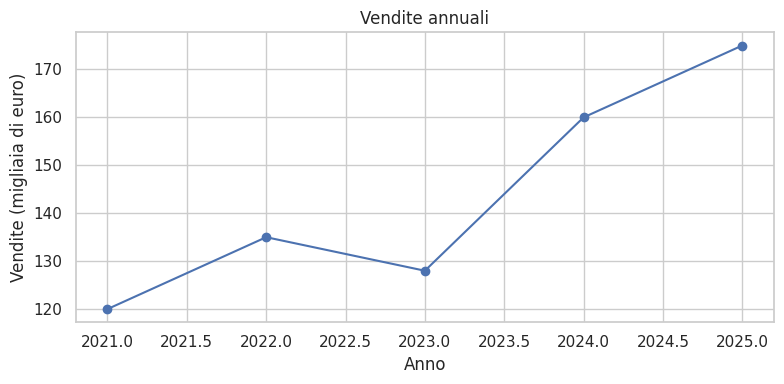

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(anni, vendite, marker="o")
ax.set_title("Vendite annuali")
ax.set_xlabel("Anno")
ax.set_ylabel("Vendite (migliaia di euro)")
fig.tight_layout()
plt.show()


Le due forme, `plt.plot(...)` e `ax.plot(...)`, producono risultati simili. In esempi brevi puoi usare `plt`; in progetti e griglie di grafici preferisci `fig, ax`.


### 5. Grafico a dispersione

Un grafico a dispersione, o scatter plot, confronta due variabili numeriche. Ogni punto è un'osservazione. Non collega i punti, perché il loro ordine non è necessariamente importante.

Creiamo un piccolo DataFrame: ogni riga rappresenta una campagna pubblicitaria.


In [5]:
campagne = pd.DataFrame({
    "budget": [10, 12, 15, 18, 20, 22, 25, 28, 30, 35],
    "vendite": [42, 45, 52, 55, 63, 60, 72, 78, 76, 88],
    "canale": ["Social", "Email", "Social", "Email", "Social",
                "Email", "Social", "Email", "Social", "Email"]
})

campagne


,budget,vendite,canale
0,10,42,Social
1,12,45,Email
2,15,52,Social
3,18,55,Email
4,20,63,Social
5,22,60,Email
6,25,72,Social
7,28,78,Email
8,30,76,Social
9,35,88,Email


Con Seaborn passiamo il DataFrame a `data` e indichiamo i nomi delle colonne. `hue` usa il colore per distinguere una terza variabile.


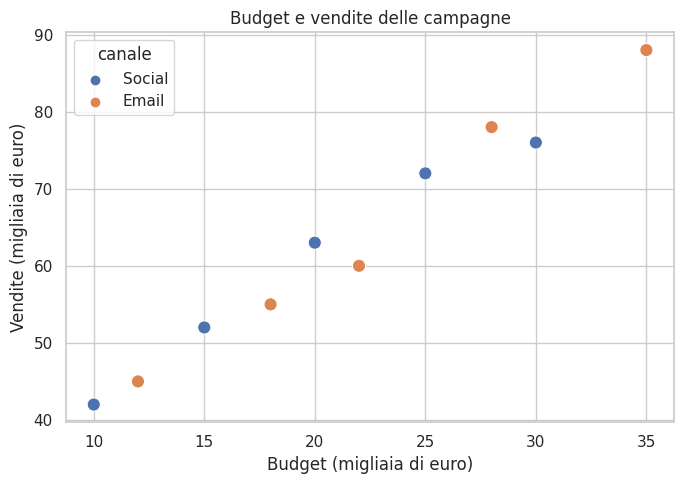

In [6]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.scatterplot(
    data=campagne,
    x="budget",
    y="vendite",
    hue="canale",
    s=90,
    ax=ax
)
ax.set_title("Budget e vendite delle campagne")
ax.set_xlabel("Budget (migliaia di euro)")
ax.set_ylabel("Vendite (migliaia di euro)")
fig.tight_layout()
plt.show()


Il grafico suggerisce un'associazione positiva: budget più alti tendono ad accompagnarsi a vendite più alte. Non dimostra però che il budget sia la causa dell'aumento. Correlazione e causalità non sono la stessa cosa.


### Esercizio 2 — dispersione

Usa `campagne` per creare un grafico con:

1. `vendite` sull'asse x;
2. `budget` sull'asse y;
3. il canale rappresentato dal colore;
4. titolo ed etichette complete.

Domanda: cambiare gli assi modifica i dati o soltanto il modo in cui li osservi?


In [ ]:
# Scrivi qui la tua soluzione


### Soluzione guidata 2

Cambiare gli assi non modifica i dati. Cambia soltanto la loro disposizione visiva.


In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.scatterplot(data=campagne, x="vendite", y="budget", hue="canale", ax=ax)
ax.set_title("Vendite e budget per canale")
ax.set_xlabel("Vendite (migliaia di euro)")
ax.set_ylabel("Budget (migliaia di euro)")
fig.tight_layout()
plt.show()


### 6. Grafico a barre

Le barre confrontano quantità tra categorie. L'asse deve partire normalmente da zero, altrimenti piccole differenze possono sembrare enormi.


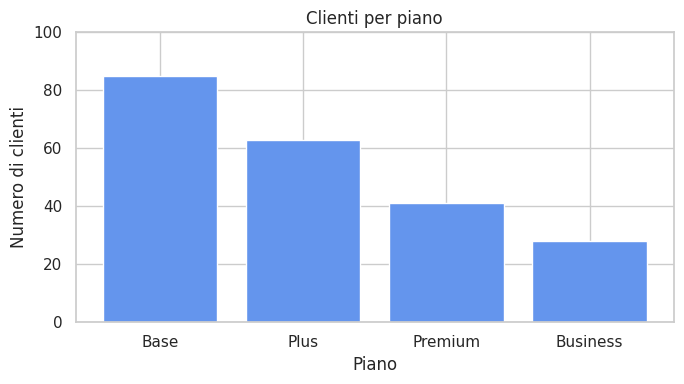

In [7]:
prodotti = ["Base", "Plus", "Premium", "Business"]
clienti = [85, 63, 41, 28]

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(prodotti, clienti, color="cornflowerblue")
ax.set_title("Clienti per piano")
ax.set_xlabel("Piano")
ax.set_ylabel("Numero di clienti")
ax.set_ylim(0, 100)
fig.tight_layout()
plt.show()


Un grafico a barre non è un istogramma:

- nelle barre, le categorie sono separate e possono essere riordinate;
- nell'istogramma, gli intervalli numerici sono adiacenti e seguono un ordine.


### 7. Istogramma

L'istogramma mostra la distribuzione di una variabile numerica. Raggruppa i valori in intervalli chiamati bin e conta quante osservazioni cadono in ciascuno.


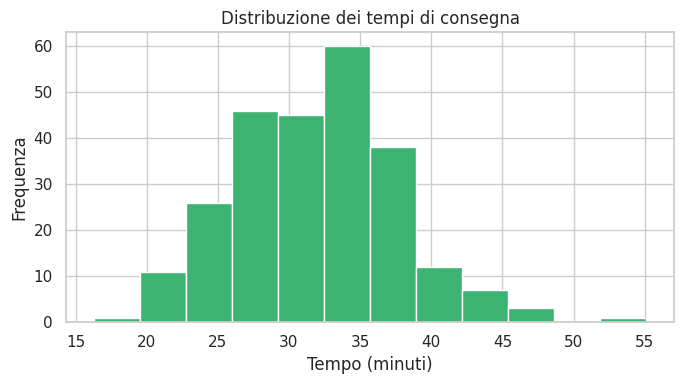

In [8]:
tempi_consegna = np.random.normal(loc=32, scale=6, size=250)

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(tempi_consegna, bins=12, color="mediumseagreen", edgecolor="white")
ax.set_title("Distribuzione dei tempi di consegna")
ax.set_xlabel("Tempo (minuti)")
ax.set_ylabel("Frequenza")
fig.tight_layout()
plt.show()


Il numero di bin influenza l'aspetto. Pochi bin nascondono dettagli; troppi mostrano rumore. Prova più valori e controlla se l'interpretazione generale rimane stabile.


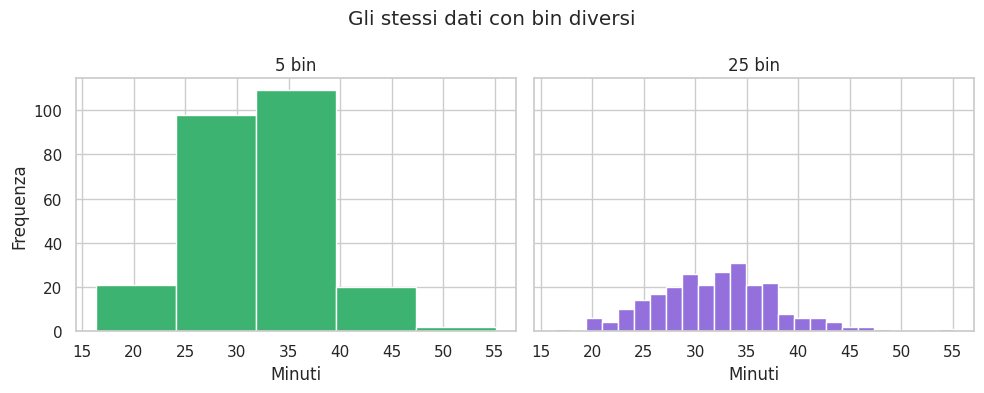

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

axes[0].hist(tempi_consegna, bins=5, color="mediumseagreen", edgecolor="white")
axes[0].set_title("5 bin")
axes[0].set_xlabel("Minuti")
axes[0].set_ylabel("Frequenza")

axes[1].hist(tempi_consegna, bins=25, color="mediumpurple", edgecolor="white")
axes[1].set_title("25 bin")
axes[1].set_xlabel("Minuti")

fig.suptitle("Gli stessi dati con bin diversi")
fig.tight_layout()
plt.show()


### Esercizio 3 — barre o istogramma?

Scegli il tipo corretto e motiva la scelta prima di scrivere codice.

1. Numero di iscritti per corso: Python 40, SQL 32, Excel 27.
2. Età di 200 partecipanti.
3. Fatturato per regione.

Poi crea il grafico del punto 1.


In [ ]:
# Scrivi qui la tua risposta e il tuo codice


### Soluzione guidata 3

I punti 1 e 3 confrontano categorie, quindi richiedono barre. Il punto 2 contiene una variabile numerica, quindi richiede un istogramma.


In [ ]:
corsi = ["Python", "SQL", "Excel"]
iscritti = [40, 32, 27]

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(corsi, iscritti, color="slateblue")
ax.set_title("Iscritti per corso")
ax.set_xlabel("Corso")
ax.set_ylabel("Numero di iscritti")
ax.set_ylim(0, 45)
fig.tight_layout()
plt.show()


### 8. Seaborn e dati in formato tabellare

Seaborn lavora bene con i DataFrame in formato lungo: ogni riga è un'osservazione e ogni colonna è una variabile.

Creiamo dati di esempio senza scaricare file da internet.


In [14]:
ordini = pd.DataFrame({
    "giorno": np.repeat(["Lun", "Mar", "Mer", "Gio", "Ven"], 8),
    "area": np.tile(np.repeat(["Nord", "Sud"], 4), 5),
    "valore": np.round(np.random.normal(55, 12, 40), 1)
})
ordini.head(10)


,giorno,area,valore
0,Lun,Nord,55.3
1,Lun,Nord,61.0
2,Lun,Nord,72.4
3,Lun,Nord,66.5
4,Lun,Sud,80.8
5,Lun,Sud,45.8
6,Lun,Sud,65.5
7,Lun,Sud,57.2
8,Mar,Nord,81.3
9,Mar,Nord,45.3


`boxplot` riassume una distribuzione. La linea nella scatola è la mediana; la scatola contiene la parte centrale dei dati; i punti lontani possono essere valori anomali. Non leggere la scatola come se fosse una barra.


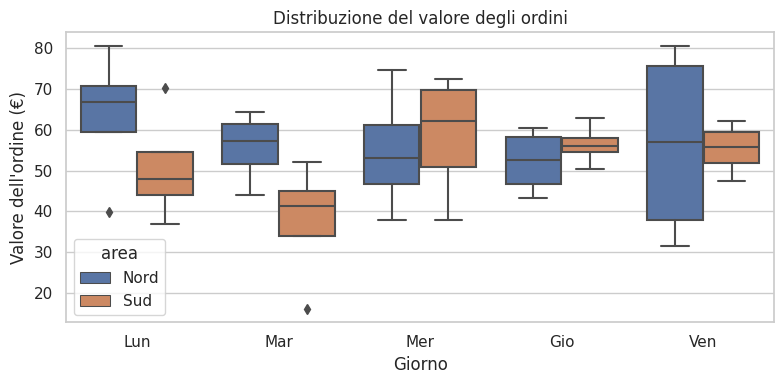

In [11]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(data=ordini, x="giorno", y="valore", hue="area", ax=ax)
ax.set_title("Distribuzione del valore degli ordini")
ax.set_xlabel("Giorno")
ax.set_ylabel("Valore dell'ordine (€)")
fig.tight_layout()
plt.show()


Seaborn può anche calcolare una media per categoria. Nel grafico seguente le barre indicano la media; le linee sottili rappresentano un intervallo di incertezza stimato. Per imparare a leggere prima le altezze, disattiviamo l'intervallo con `errorbar=None`.


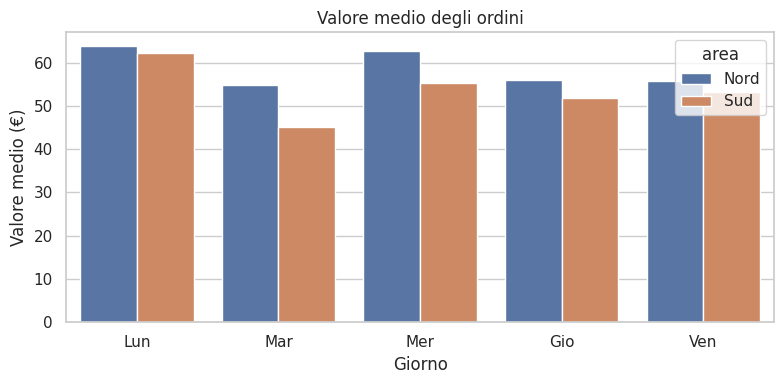

In [15]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=ordini, x="giorno", y="valore", hue="area", errorbar=None, ax=ax)
ax.set_title("Valore medio degli ordini")
ax.set_xlabel("Giorno")
ax.set_ylabel("Valore medio (€)")
fig.tight_layout()
plt.show()


### 9. Heatmap

Una heatmap rappresenta una matrice tramite colori. È utile per tabelle a due dimensioni e correlazioni.

Prima costruiamo una tabella con righe, colonne e valori; poi annotiamo ogni cella con il numero corrispondente.


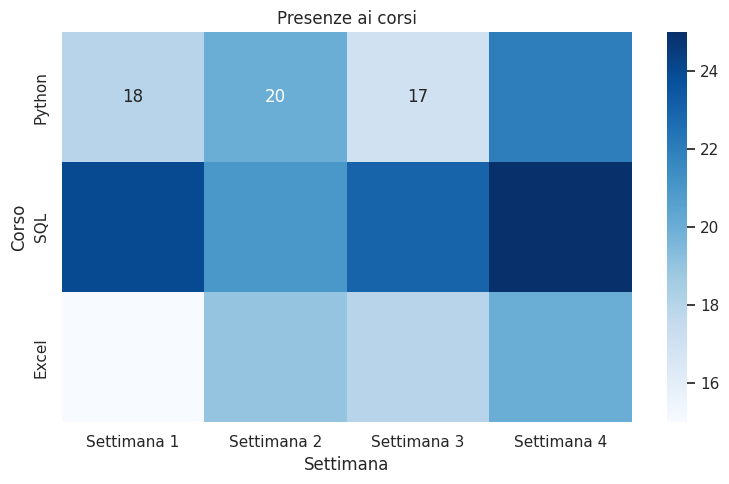

In [22]:
presenze = pd.DataFrame(
    [[18, 20, 17, 22],
     [24, 21, 23, 25],
     [15, 19, 18, 20]],
    index=["Python", "SQL", "Excel"],
    columns=["Settimana 1", "Settimana 2", "Settimana 3", "Settimana 4"]
)

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(presenze, annot=True, fmt="d", cmap="Blues", ax=ax)
ax.set_title("Presenze ai corsi")
ax.set_xlabel("Settimana")
ax.set_ylabel("Corso")
fig.tight_layout()
plt.show()


Il colore riassume rapidamente l'intensità, mentre i numeri permettono una lettura precisa. Controlla sempre la scala dei colori a destra.


### 10. Correlazioni

La correlazione misura quanto due variabili numeriche si muovono insieme in modo lineare. Varia da -1 a 1:

- vicino a 1: relazione lineare positiva;
- vicino a -1: relazione lineare negativa;
- vicino a 0: assenza di una chiara relazione lineare.

Non implica causalità.


In [20]:
campagne

,budget,vendite,canale
0,10,42,Social
1,12,45,Email
2,15,52,Social
3,18,55,Email
4,20,63,Social
5,22,60,Email
6,25,72,Social
7,28,78,Email
8,30,76,Social
9,35,88,Email


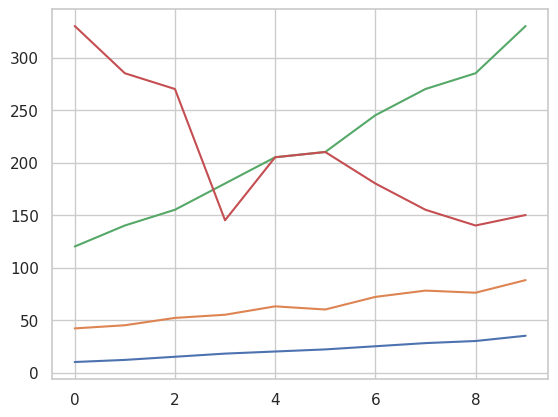

In [35]:
plt.plot(campagne.iloc[:,0])
plt.plot(campagne.iloc[:,1])
plt.plot(metriche.iloc[:,2])
plt.plot(metriche.iloc[:,3])


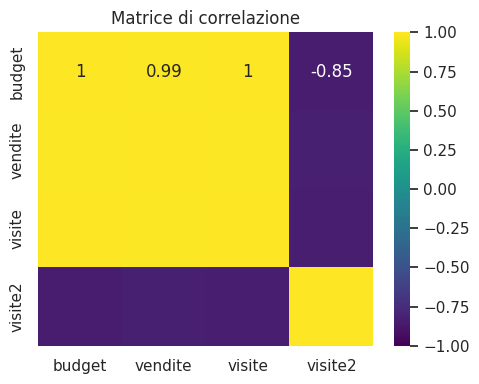

In [37]:
metriche = pd.DataFrame({
    "budget": campagne["budget"],
    "vendite": campagne["vendite"],
    "visite": [120, 140, 155, 180, 205, 210, 245, 270, 285, 330],
    "visite2": [330, 285, 270, 145, 205, 210, 180, 155, 140, 150]

})
correlazioni = metriche.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(correlazioni, annot=True, vmin=-1, vmax=1, cmap="viridis", ax=ax)
ax.set_title("Matrice di correlazione")
fig.tight_layout()
plt.show()


### 11. Più grafici nella stessa figura

`plt.subplots(righe, colonne)` crea una griglia. Qui `axes[0]` e `axes[1]` sono i due assi. Passare `ax=...` a Seaborn evita che il grafico finisca nel posto sbagliato.


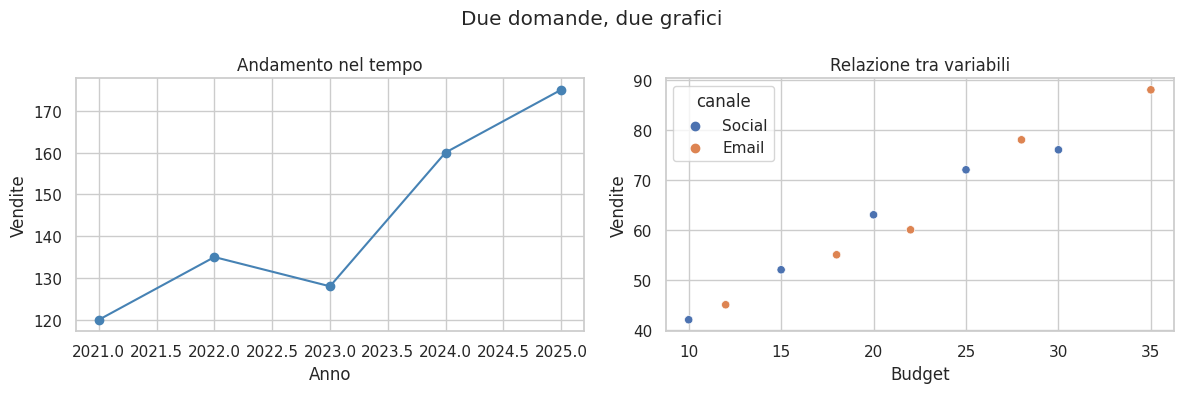

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(anni, vendite, marker="o", color="steelblue")
axes[0].set_title("Andamento nel tempo")
axes[0].set_xlabel("Anno")
axes[0].set_ylabel("Vendite")

sns.scatterplot(data=campagne, x="budget", y="vendite", hue="canale", ax=axes[1])
axes[1].set_title("Relazione tra variabili")
axes[1].set_xlabel("Budget")
axes[1].set_ylabel("Vendite")

fig.suptitle("Due domande, due grafici")
fig.tight_layout()
plt.show()


### 12. Salvare una figura

Chiama `savefig` prima di `plt.show()`. `dpi=150` offre una buona risoluzione per molti usi; `bbox_inches="tight"` riduce i bordi vuoti.

La cella seguente crea `vendite_annuali.png` nella cartella del notebook.


In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(anni, vendite, marker="o", color="steelblue")
ax.set_title("Vendite annuali")
ax.set_xlabel("Anno")
ax.set_ylabel("Vendite (migliaia di euro)")
fig.tight_layout()
fig.savefig("vendite_annuali.png", dpi=150, bbox_inches="tight")
plt.show()


### 13. Una piccola guida alla scelta

- andamento nel tempo → grafico a linee;
- relazione tra due numeri → grafico a dispersione;
- confronto tra categorie → grafico a barre;
- distribuzione di un numero → istogramma o boxplot;
- valori in una matrice → heatmap;
- più domande collegate → subplots separati.

Prima di creare un grafico chiediti: quale domanda deve risolvere? quali sono le unità? ogni elemento visivo rappresenta davvero una variabile utile?


### 14. Errori comuni

- Dimenticare titolo, unità o legenda.
- Usare una linea per categorie senza un ordine naturale.
- Confondere barre e istogrammi.
- Tagliare l'asse delle barre e amplificare differenze piccole.
- Usare troppi colori, effetti o decorazioni.
- Concludere che una correlazione dimostri una causa.
- Mostrare un grafico senza spiegare la domanda e il messaggio principale.

Un grafico sobrio non è incompleto: elimina ciò che non aiuta a capire i dati.


### Progetto finale

Crea un DataFrame con almeno 12 righe e queste colonne:

- `mese`;
- `ricavi`;
- `costi`;
- `area` con almeno due categorie.

Poi realizza:

1. una linea per ricavi e una per costi, con legenda;
2. uno scatter plot tra costi e ricavi, colorato per area;
3. un grafico a barre dei ricavi medi per area;
4. una figura con i primi due grafici affiancati;
5. una frase sotto ogni grafico che descriva ciò che osservi senza parlare di causalità.

Controllo finale:

- il tipo di grafico risponde alla domanda;
- assi e unità sono chiari;
- colori e legenda hanno uno scopo;
- il codice viene eseguito dall'inizio senza errori.


In [ ]:
# Costruisci qui il tuo progetto finale


### Riepilogo

Hai imparato a costruire grafici con Matplotlib, a usare Seaborn con i DataFrame e a distinguere i principali tipi di visualizzazione. Hai anche visto figura e assi, subplots, heatmap, correlazioni e salvataggio su file.

Il passo successivo è ripetere gli esercizi con dati tuoi. La competenza più importante non è ricordare ogni parametro, ma scegliere un grafico coerente e spiegare con chiarezza cosa mostra.
